In [1]:
!pip install imagecodecs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 73.7 MB/s eta 0:00:00:00:0100:01


In [2]:
import os
import torch
import torch.nn.functional as F
import tifffile 
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import warnings
from pathlib import Path
from typing import Tuple, Optional, Dict, List, Callable,Union
import pytorch_lightning as pl
import random

# Declare the paths
DATA_DIR = Path("/kaggle/input/competitions/vesuvius-challenge-surface-detection")
TRAIN_IMAGES_DIR = Path("/kaggle/input/competitions/vesuvius-challenge-surface-detection/train_images")
TRAIN_LABELS_DIR = Path("/kaggle/input/competitions/vesuvius-challenge-surface-detection/train_labels")
MODEL_INPUT_SIZE = (256, 256, 256)  # (depth, height, width) - standarize volume size to this
# For training
BATCH_SIZE = 1
NUM_WORKERS = 2

In [3]:
#### Our Previous resize 3D class to replace pytorch transforms
class Resize3D:
    """
    Resizing class separately written because Pytorch transforms doesn't directly handle 3d volumes :(
    """
    def __init__(self, size=(256, 256, 256)):
        self.size = size
        
    def __call__(self, volume_tensor):
        # As per pytorch, the dataset has to be 5D arranged as [Batch, Channel, Depth, Height, Width]
        # volume_tensor shape expected: [Channel, Depth, Height, Width]
        volume_tensor = volume_tensor.unsqueeze(0) # Add Batch dim -> [1, C, D, H, W]       
        resized_volume = F.interpolate(
            volume_tensor, size=self.size, mode='trilinear', align_corners=False
        )
        return resized_volume # Remove Batch dim for stacking later

In [4]:
### Surface dataset class, the new addition
class SurfaceDataset3D(Dataset):
    def __init__(self,images_dir: Path,labels_dir: Optional[Path],volume_files: Optional[List[str]] = None,
        volume_shape: Tuple[int, int, int] = (256, 256, 256),):
        """Initialize the file paths, saves the volume shapes"""
        super().__init__()
        self.images_dir = images_dir
        self.labels_dir = labels_dir 
        self.volume_files = volume_files
        self.volume_shape = volume_shape
        self._prepare_volume_files()
    
    def _prepare_volume_files(self):
        """Scan the path and get a list of all the tif files (since our data is tif)"""
        if self.volume_files is None:
             print(f"No volume files specified. Scanning {self.images_dir}...")
             self.volume_files = sorted([p.name for p in self.images_dir.glob(f"*{".tif"}")])
        valid_files = []
        for filename in self.volume_files:
            valid_files.append(filename)
        self.volume_files = valid_files
        print(f"Found {len(self.volume_files)} volumes.")
    
    def __len__(self) -> int:
        return len(self.volume_files)  ### Just returning length of volume files
    
    def __getitem__(self, idx: int):
        """Similar to standard __getitem__ methods. Loads a single sample of image and labels
        """
        filename = self.volume_files[idx]
        image, mask = self._load_from_raw(filename)
        
        # Convert to Tensor (Channel dimension added here: [1, D, H, W])
        image_t = torch.from_numpy(image).float().div_(255.0).unsqueeze(0)

        if mask is not None:
             mask_t = torch.from_numpy(mask).long().unsqueeze(0)
        else:
             mask_t = torch.full_like(image_t, 2, dtype=torch.long) ## The type casting is a topic for another day!

        frag_id = Path(filename).stem
        return image_t, mask_t, frag_id

    def _load_file(self, path: Path) -> np.ndarray:
        return tifffile.imread(str(path)) ### read the tiffile from the path

    def _load_from_raw(self, volume_file: str) -> Tuple[np.ndarray, Optional[np.ndarray]]:
        """Method to read the volumes and labels and save it as numpy array"""
        image_path = self.images_dir / volume_file
        image_volume = self._load_file(image_path)
        label_volume = None
        return image_volume, label_volume

In [5]:
def custom_collate(batch):
    return batch

In [6]:
### SurfaceDataLoader class
class SurfaceDataLoader(pl.LightningDataModule):
    def __init__(self,train_images_dir: Path,train_labels_dir: Path,volume_shape: Tuple[int, int, int] = (256, 256, 256), 
        val_split: float = 0.1,batch_size: int = BATCH_SIZE, num_workers: int = NUM_WORKERS):
        """Sets up the hyperparameters (batch size, workers etc.) and initializes the Resize3D tool, 
        which will be used later on the GPU."""
        super().__init__()
        self.train_images_dir = train_images_dir
        self.train_labels_dir = train_labels_dir
        self.volume_shape = volume_shape
        self.val_split = val_split
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.gpu_resizer = Resize3D(size=self.volume_shape) # Apply transform using pytorch resize3D

    def setup(self, stage: Optional[str] = None):
        #Shuffle and split data into train and val 
        print(f"\nSetting up training data...")
        all_files = sorted([f.name for f in self.train_images_dir.glob(f"*{".tif"}")])
        random.seed(42)
        random.shuffle(all_files)
        split_idx = int(len(all_files) * (1 - self.val_split))
        train_files = all_files[:split_idx]
        val_files = all_files[split_idx:]

        self.train_dataset = SurfaceDataset3D(
            images_dir=self.train_images_dir,
            labels_dir=self.train_labels_dir,
            volume_files=train_files,
            volume_shape=self.volume_shape
        )
        self.val_dataset = SurfaceDataset3D(
            images_dir=self.train_images_dir,
            labels_dir=self.train_labels_dir,
            volume_files=val_files,
            volume_shape=self.volume_shape
        )

    def train_dataloader(self) -> DataLoader:
        # Wrap train dataset in a standard PyTorch dataloader
        return DataLoader(
            self.train_dataset,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=bool(self.num_workers > 0),
            collate_fn=custom_collate
        )

    def val_dataloader(self) -> DataLoader:
        # Wrap val dataset in a standard PyTorch dataloader
        return DataLoader(
            self.val_dataset,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=self.num_workers,
            pin_memory=True,
            persistent_workers=bool(self.num_workers > 0),
            collate_fn=custom_collate
        )

    def on_after_batch_transfer(self, batch, dataloader_idx):
        ## The main optimization hack
        if not isinstance(batch, list):
            return super().on_after_batch_transfer(batch, dataloader_idx)

        x_list, y_list, frag_ids = [], [], []
        device = self.trainer.strategy.root_device if self.trainer else torch.device("cuda" if torch.cuda.is_available() else "cpu")

        for item in batch:
            x, y, frag_id = item
            # Move to GPU
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            # Apply Resize3D
            x_resized = self.gpu_resizer(x)
            y_resized = self.gpu_resizer(y.float()).long()
            
            x_list.append(x_resized)
            y_list.append(y_resized)
            frag_ids.append(frag_id)

        # Final Batch Shape: [B, C, D, H, W]
        return torch.stack(x_list), torch.stack(y_list), frag_ids

In [7]:
datamodule = SurfaceDataLoader(
    train_images_dir=TRAIN_IMAGES_DIR,
    train_labels_dir=TRAIN_LABELS_DIR,
    volume_shape=MODEL_INPUT_SIZE,
)
datamodule.setup()

datamodule.volume_shape


Setting up training data...
Found 707 volumes.
Found 79 volumes.


(256, 256, 256)

torch.Size([1, 320, 320, 320])


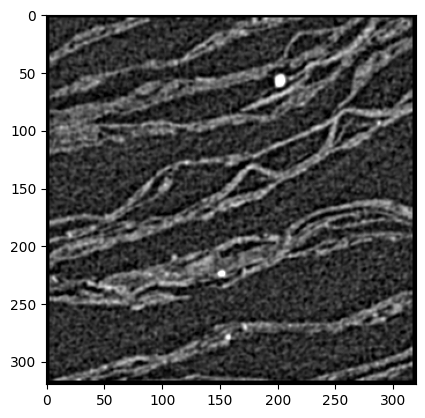

In [8]:
# 1. Get a raw batch from the training loader
train_loader = datamodule.train_dataloader()
batch = next(iter(train_loader))

# Extract the first sample (raw_img: 320x320x320)
raw_img, raw_mask, frag_id = batch[0]
print (raw_img.shape)

import matplotlib.pyplot as plt
plt.imshow(raw_img.squeeze()[0], cmap="gray")